----
# **<span style="color:darkmagenta">PROYECTO EDA - BANK MARKETING</span>**
----

---
---
## <span style="color:gray">**1. Importación de librerías**</span> 📂

In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd 

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Configuración de ruta
import sys
sys.path.append('../')

# Importación de funciones personalizadas
from src.soporte import columnas_df
from src.soporte import boxplots
from src.soporte import graficos_categoricos
from src.soporte import number_vs_target
from src.soporte import tasa_conversion_cat
from src.soporte import grafs_conversion_cat


---
---
## <span style="color:gray">**2. Carga de datos**</span> 📥

In [2]:
# Utilizamos los datos que hemos guardado tras la limpieza
bank_data_limpio = pd.read_csv("../data/output/bank_data_limpio.csv")
customer_data_limpio = pd.read_csv("../data/output/customer_data_limpio.csv")

In [3]:
# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None) 

----
# <span style="color:darkmagenta">**Desarrollo del proyecto - 3**</span> 
----


---
---
## <span style="color:gray">**Integración de datasets**</span> 🔗

In [4]:
df_integrado = pd.merge(bank_data_limpio, customer_data_limpio, on='id', how='left')

# Lo guardamos en un csv
df_integrado.to_csv("../data/output/df_integrado.csv", index=False)

Recordamos la estructura del dataset:

In [5]:
df_integrado.head(3)

,age,job,marital_status,education_level,default,housing_loan,personal_loan,contact_method,campaign_contacts,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_employees,subscribed,id,contacted_before,year,month,income,num_kids_home,num_teens_home,customer_since,num_web_visits_month
0,38,housemaid,married,basic_4y,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857000,5191,no,089b39d8-e4d0-461b-87d4-814d71e0e079,no,2019,August,161770,1,0,2012-04-04,29
1,57,services,married,high_school,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,3.616521,5191,no,e9d37224-cb6f-4942-98d7-46672963d097,no,2016,September,85477,1,1,2012-12-30,7
2,37,services,married,high_school,no,si,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857000,5191,no,3f9f49b5-e410-4948-bf6e-f9244f04918b,no,2019,February,147233,1,1,2012-02-02,5


La columna `id` la podemos eliminar ya que solo la necesitábamos para la integración de los dataset

In [6]:
df_integrado = df_integrado.drop('id', axis=1)

In [7]:
columnas_df(df_integrado)

Las columnas del DataFrame que estamos analizando son:


Index(['age', 'job', 'marital_status', 'education_level', 'default',
       'housing_loan', 'personal_loan', 'contact_method', 'campaign_contacts',
       'previous_contacts', 'previous_campaign_outcome',
       'employment_variation_rate', 'consumer_price_index',
       'consumer_confidence_index', 'euribor_3m_rate', 'number_employees',
       'subscribed', 'contacted_before', 'year', 'month', 'income',
       'num_kids_home', 'num_teens_home', 'customer_since',
       'num_web_visits_month'],
      dtype='str')

Información básica de las columnas:

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        43000 non-null  int64  
 1   job                        43000 non-null  str    
 2   marital_status             43000 non-null  str    
 3   education_level            43000 non-null  str    
 4   default                    43000 non-null  str    
 5   housing_loan               43000 non-null  str    
 6   personal_loan              43000 non-null  str    
 7   contact_method             43000 non-null  str    
 8   campaign_contacts          43000 non-null  int64  
 9   previous_contacts          43000 non-null  int64  
 10  previous_campaign_outcome  43000 non-null  str    
 11  employment_variation_rate  43000 non-null  float64
 12  consumer_price_index       43000 non-null  float64
 13  consumer_confidence_

,count,mean,std,min,25%,50%,75%,max
age,43000.0,39.74,9.82,17.00,33.00,38.00,46.00,98.00
campaign_contacts,43000.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
previous_contacts,43000.0,0.17,0.50,0.00,0.00,0.00,0.00,7.00
employment_variation_rate,43000.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
consumer_price_index,43000.0,93.57,0.58,92.20,93.08,93.57,93.99,94.77
consumer_confidence_index,43000.0,-40.51,4.64,-50.80,-42.70,-41.80,-36.40,-26.90
euribor_3m_rate,43000.0,3.62,1.54,0.63,1.47,4.08,4.96,5.04
number_employees,43000.0,5166.84,72.34,4964.00,5099.00,5191.00,5228.00,5228.00
year,43000.0,2017.01,1.42,2015.00,2016.00,2017.00,2018.00,2019.00
income,43000.0,93241.20,50498.32,5841.00,49610.00,93050.50,136744.50,180802.00



Estadísticos de las variables categóricas:



,count,unique,top,freq
job,43000,12,administrative,10873
marital_status,43000,4,married,25999
education_level,43000,8,university_degree,12722
default,43000,2,no,42997
housing_loan,43000,2,si,22498
personal_loan,43000,2,no,36468
contact_method,43000,2,cellular,27396
previous_campaign_outcome,43000,3,nonexistent,37103
subscribed,43000,2,no,38156
contacted_before,43000,2,no,41412


In [8]:
cols_fecha = ['customer_since']
for col in cols_fecha:
    df_integrado[col] = pd.to_datetime(df_integrado[col])

---
---
## <span style="color:gray">**EDA sobre el dataset final**</span> 🧩

---

### <span style="color:darkgray">**1. Análisis univariado**</span>  

### <span style="color:darkgray">Distribución de las columnas numéricas</span>

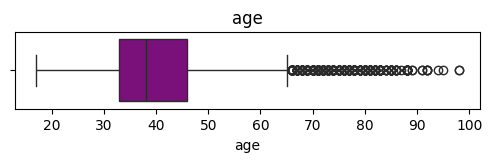

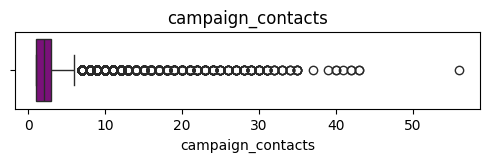

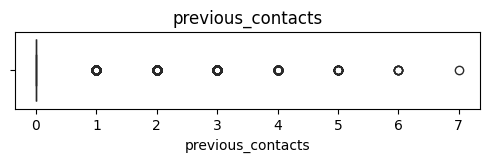

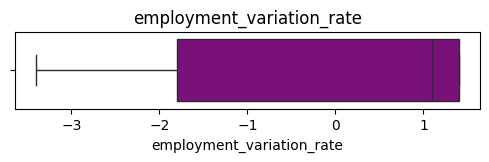

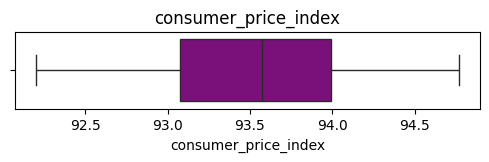

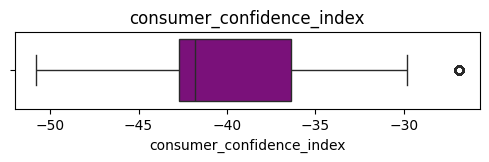

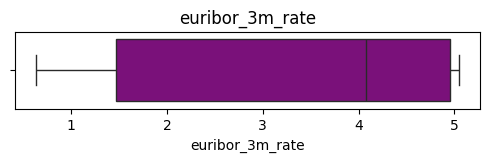

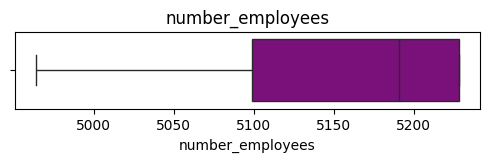

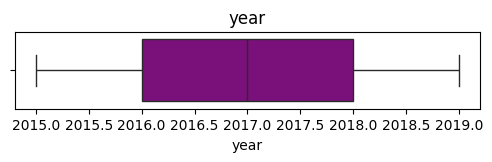

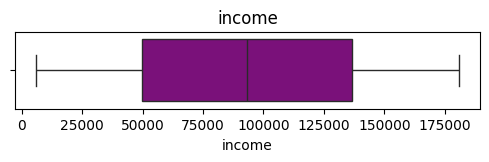

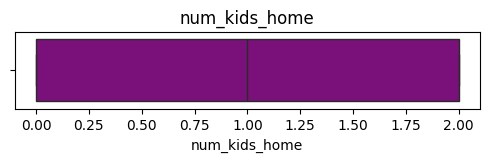

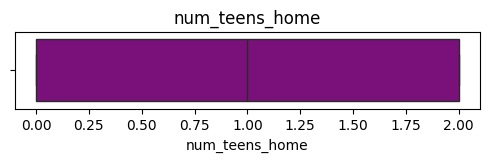

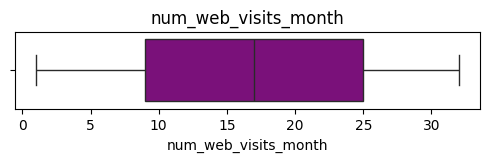

In [9]:
# Llamamos a la función de boxplots guardada en el documento soporte.py
boxplots(df_integrado)

| Variable | Rango / Valores | Mediana | Observaciones |
|----------|----------------|---------|---------------|
| `age` | 18 – 100 | ~40 | La mayoría entre 30–50; varios outliers altos (70–100). |
| `campaign_contacts` | 1 – ~50 | 1–5 | Concentrado en valores bajos; algunos clientes reciben muchos contactos. |
| `previous_contacts` | 0 – 7 | 0 | Mayoría sin contactos previos; pocos casos dispersos. |
| `employment_variation_rate` | -3 a +1.5 | >0 | Distribución amplia, indica variación económica. |
| `consumer_price_index` | 92.5 – 94.8 | 93.7 | Poca variabilidad; indicador económico estable. |
| `consumer_confidence_index` | -50 a -30 | -40 | Algunos outliers; refleja cambios puntuales en confianza del consumidor. |
| `euribor_3m_rate` | 1 – 5 | ~4 | Amplia variación en tasas de interés. |
| `number_employees` | 5000 – 5220 | ~5150 | Muy poca variabilidad; empresa estable en tamaño. |
| `year` | 2016-2018 | 2017 | Distribución relativamente simétrica. |
| `income` | 0 – 175000 | 80k–90k | Rango amplio; algunos clientes con ingresos muy altos. |
| `num_kids_home` | 0 – 2 | 1 | Distribución bastante uniforme; pocos casos extremos. |
| `num_teens_home` | 0 – 2 | 1 | Similar a `num_kids_home`; sin outliers. |
| `num_web_visits_month` | 1 – 32 | 15–18 | Distribución equilibrada. |

**Resumen general**

- Variables económicas (índices, tasas) → más estables o controladas

- Variables de comportamiento (contactos, visitas) → más dispersas y con outliers

- Variables demográficas (edad, hijos, ingresos) → muestran diversidad clara en clientes

A partir del análisis anterior, se ha identificado que las siguientes variables presentan una baja relevancia explicativa debido a su escasa variabilidad o limitada capacidad informativa:

`previous_contacts` 

- Esta variable muestra una alta concentración de valores en 0, por lo que esta variable apenas aporta información relevante.

`num_kids_home` / `num_teens_home`

- Estas variables tienen muy poca variación entre los registros, lo que dificulta que ayuden a diferenciar unos casos de otros.

`number_employees`

- Se observa que esta variable es prácticamente constante, por lo que no aporta información significativa para el análisis.


En consecuencia, eliminamos estas variables del conjunto de datos para simplificar el modelo y evitar que introduzcan ruido innecesario:

- Antes de eliminarlas, creamos una copia del DataFrame:

In [10]:
df_final = df_integrado.copy()

- Eliminamos las varibles mencionadas anteriormente:

In [11]:
cols_eliminar = ['previous_contacts', 'num_kids_home', 'num_teens_home', 'number_employees']

df_final = df_final.drop(columns=cols_eliminar)

- Guardamos el DataFrame:

In [12]:
df_final.to_csv("../data/output/df_final.csv", index=False)

---
### <span style="color:darkgray">Distribución de las columnas categóricas</span>

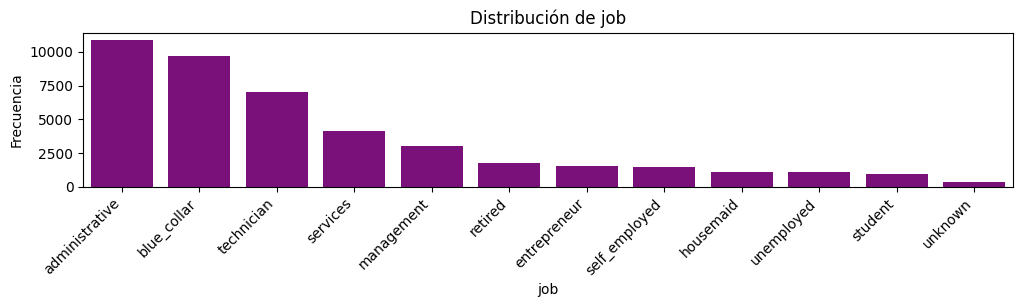

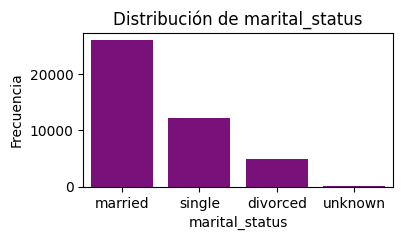

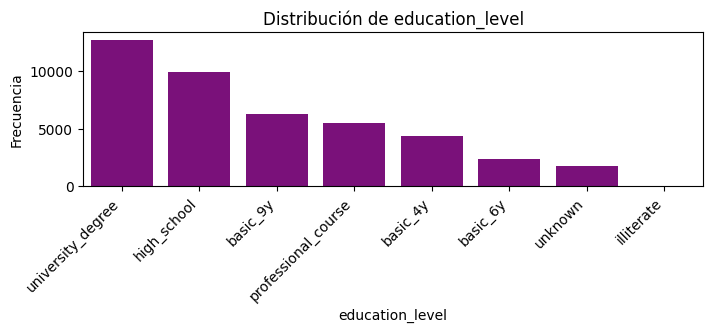

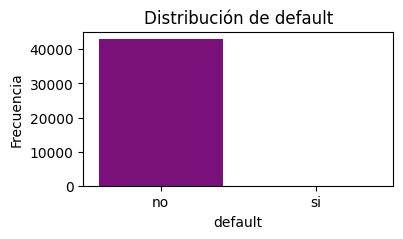

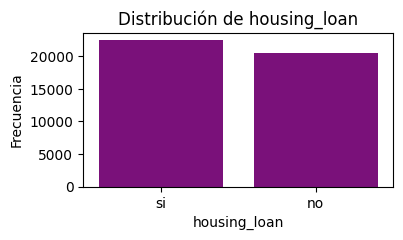

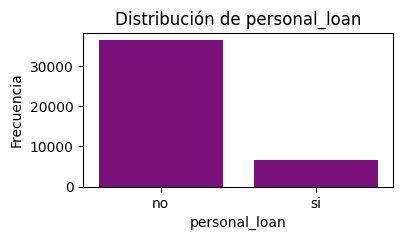

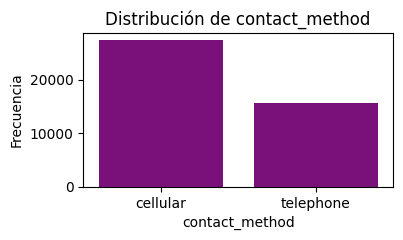

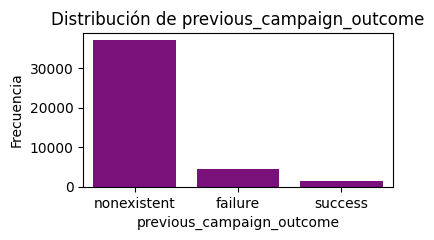

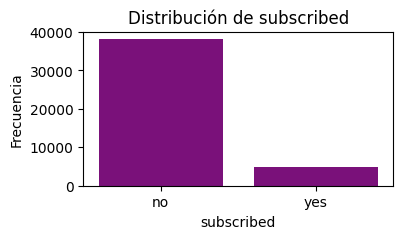

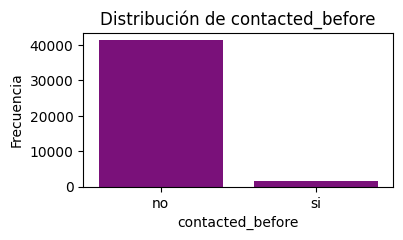

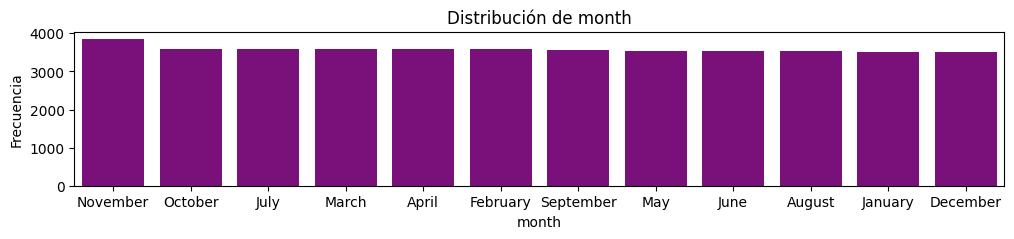

In [13]:
# Llamamos a la función de graficos_categoricos guardada en el documento soporte.py
graficos_categoricos(df_final, rotar_columnas=['job', 'education_level'])

| Variable                     | Predomina                                      | Observaciones                                                                 |
|-----------------------------|-----------------------------------------------|------------------------------------------------------------------------------|
| `job`                       | *administrative, blue-collar, technician*       | La mayoría pertenece a trabajos técnicos o administrativos.                 |
| `marital_status`            | *married, single*                                       | La mayoría de los clientes están casados.                                                         |
| `education_level`           | *university degree, high school*                | Predominan niveles educativos medios y superiores.                          |
| `default`                   | *no*                                            | Muy pocos clientes han incumplido pagos.                                    |
| `housing_loan`              | Ligeramente *yes*                               | Distribución bastante equilibrada.                                          |
| `personal_loan`             | *no*                                            | La mayoría no tiene préstamo personal.                                      |
| `contact_method`            | *mobile*                                        | Se usa más el móvil que el teléfono fijo.                                   |
| `previous_campaign_outcome` | *nonexistent*                                   | Muy pocos casos de success; muchos no fueron contactados antes.             |
| `subscribed`                | *no*                                            | Dataset desbalanceado (clase *no* mucho mayor que *yes*).                       |
| `contacted_before`          | *no*                                            | Confirma que la mayoría de los clientes no había sido contactada previamente.            |
| `month`                     | Ligeramente *November*                          | Distribución bastante equilibrada.            |

---
### <span style="color:darkgray">**2. Análisis bivariado**</span>  

### <span style="color:darkgray">Relación entre columnas numéricas y suscripción</span>  

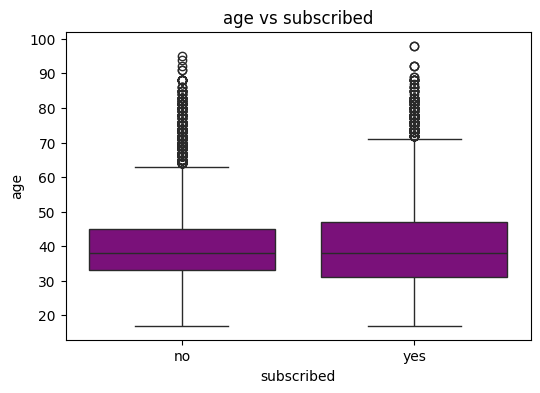

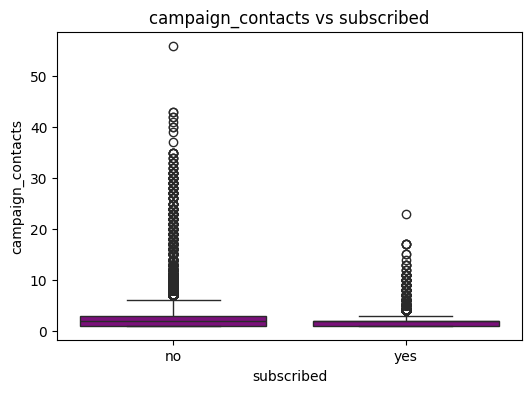

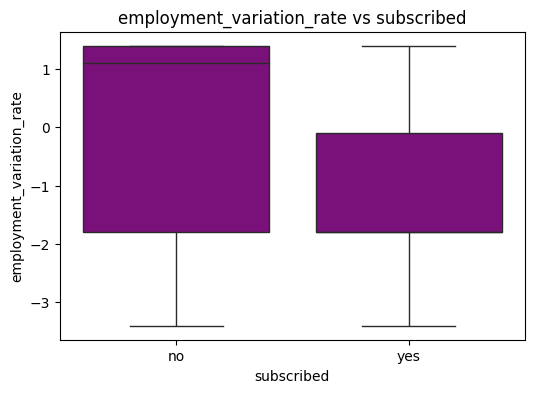

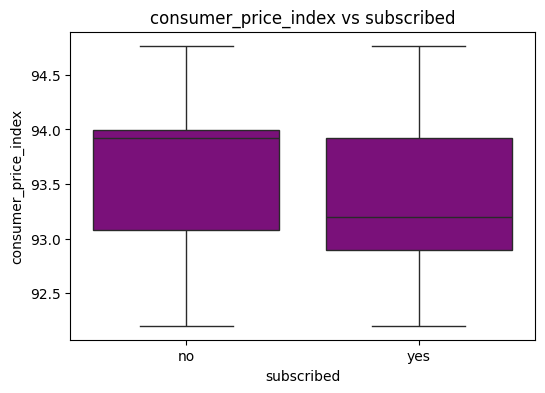

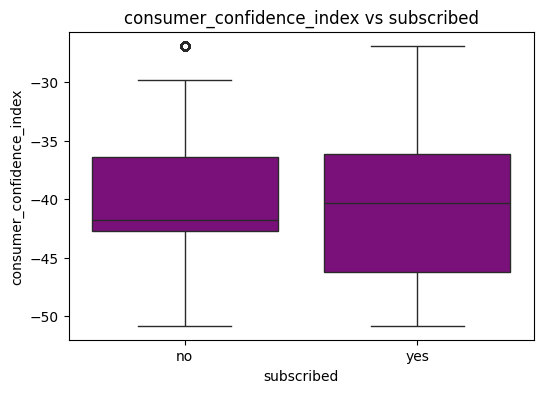

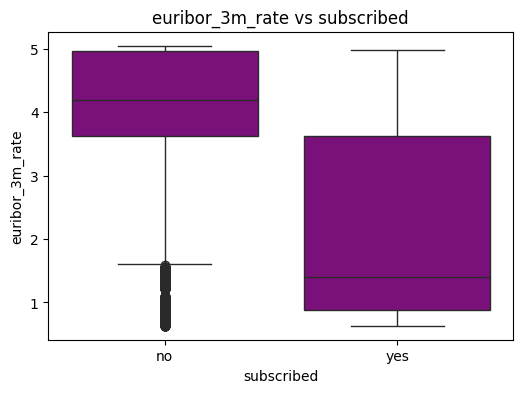

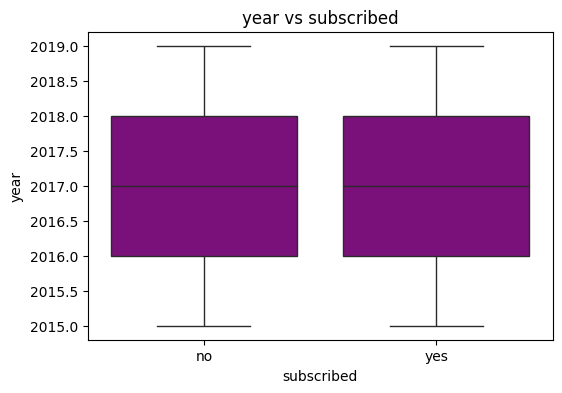

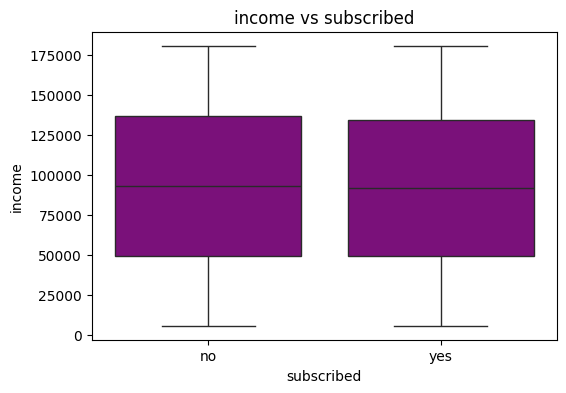

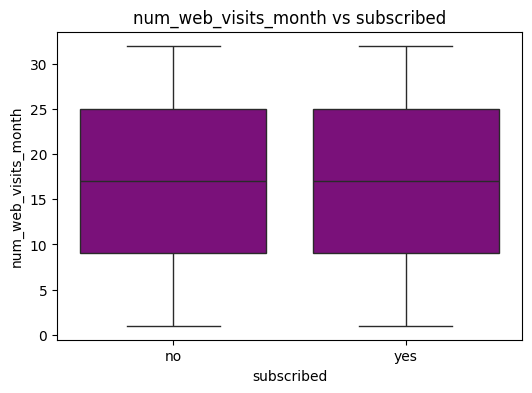

In [14]:
# Llamamos a la función de number_vs_target guardada en el documento soporte.py
number_vs_target(df_final, "subscribed")

***age* vs *subscribed***

- La mediana de edad para quienes se suscriben (yes) y no se suscriben (no) es bastante similar, alrededor de 35 años.
- La mayoría de los suscriptores están en el rango de 30–45 años.
- Hay varios valores atípicos en ambos grupos, especialmente por encima de los 60 años.

Conclusión: La edad por sí sola no parece un factor determinante fuerte para suscribirse.

***campaign_contacts* vs *subscribed***

- La mayoría de las personas han sido contactadas pocas veces (0–5) durante la campaña.
- Los no suscriptores muestran más valores atípicos en los contactos de campaña, con algunos recibiendo hasta 50 contactos.

Conclusión: Recibir más contactos no garantiza suscripción; de hecho, muchos que no se suscriben reciben más contactos, lo que sugiere saturación o contactos repetitivos sin éxito.

***employment_variation_rate* vs *subscribed***

- Los suscriptores tienden a tener una tasa de variación del empleo más baja (más cercana a cero o positiva), mientras que los no suscriptores tienen valores negativos más pronunciados.

Conclusión: Una economía o sector laboral más estable podría estar correlacionado con la suscripción.

***consumer_price_index* vs *subscribed***

- No hay una diferencia clara entre suscriptores y no suscriptores.
- La mediana y el rango son prácticamente iguales.

Conclusión: CPI no parece influir directamente en la decisión de suscribirse.

***consumer_confidence_index* vs *subscribed***

- Los valores medianos son similares entre ambos grupos.
- Hay algunos outliers positivos en los no suscriptores.

Conclusión: La confianza del consumidor no muestra un patrón claro con la suscripción.

***euribor_3m_rate* vs *subscribed***

- Los suscriptores tienden a registrarse cuando la tasa Euribor a 3 meses es más baja.
- Los no suscriptores muestran tasas más altas y más dispersión.

Conclusión: Las tasas de interés bajas podrían favorecer la suscripción.

***year* vs *subscribed***

- La distribución por años es muy similar entre suscriptores y no suscriptores.

Conclusión: El año de registro no influye significativamente en la suscripción.

***income* vs *subscribed***

- La mediana de ingresos es similar para ambos grupos.
- Ambos muestran una distribución amplia y outliers altos.

Conclusión: Los ingresos individuales no parecen ser un predictor fuerte de suscripción.

***num_web_visits_month* vs *subscribed***

- La mediana y rango son casi idénticos para ambos grupos.

Conclusión: La cantidad de visitas web al mes no diferencia claramente entre suscriptores y no suscriptores.



### <span style="color:darkgray">Relación entre columnas categóricas y suscripción</span>  

Calculamos la tasa de conversión para cada categoría de las variables categóricas:

In [15]:
tasa_conversion_cat(df_final, 'subscribed')

Variable: job
job
student           31.34
retired           25.20
unemployed        14.39
administrative    13.01
unknown           11.30
management        11.21
technician        10.85
self_employed     10.81
housemaid          9.88
entrepreneur       8.28
services           8.07
blue_collar        6.89
Name: subscribed, dtype: float64
--------------------------------------------------
Variable: marital_status
marital_status
unknown     15.29
single      13.93
married     10.21
divorced    10.18
Name: subscribed, dtype: float64
--------------------------------------------------
Variable: education_level
education_level
illiterate             22.22
unknown                14.44
university_degree      13.74
professional_course    11.32
high_school            10.84
basic_4y               10.28
basic_6y                8.13
basic_9y                7.81
Name: subscribed, dtype: float64
--------------------------------------------------
Variable: default
default
no    11.27
si     0.00
Name: 

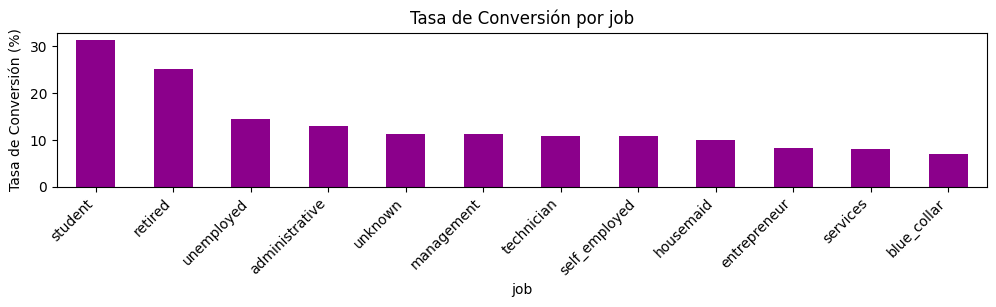

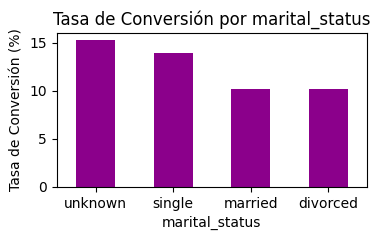

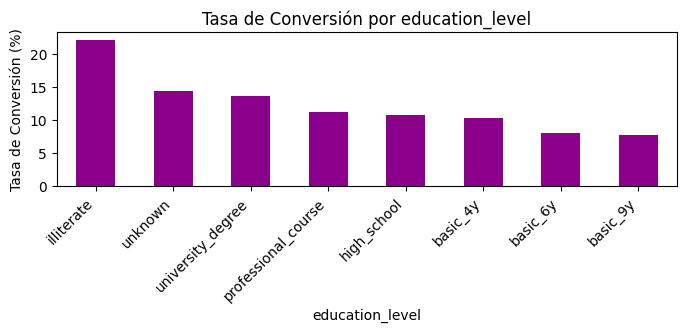

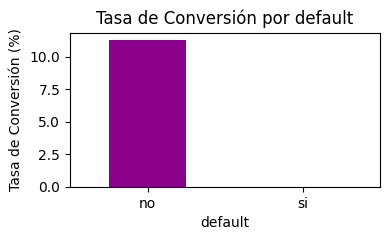

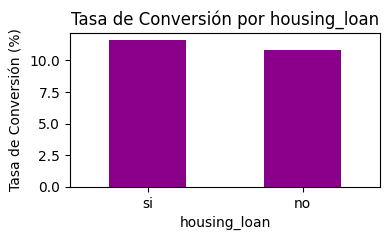

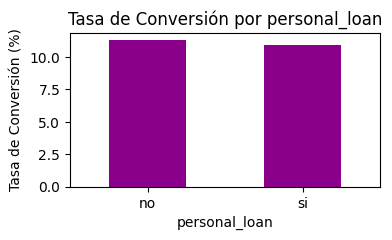

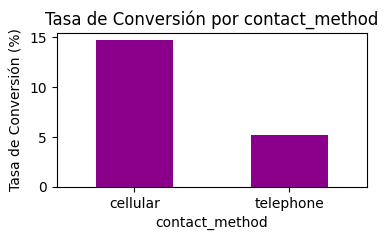

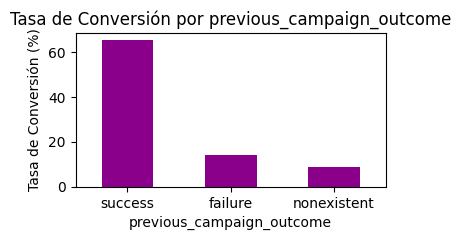

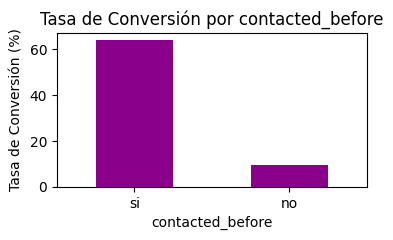

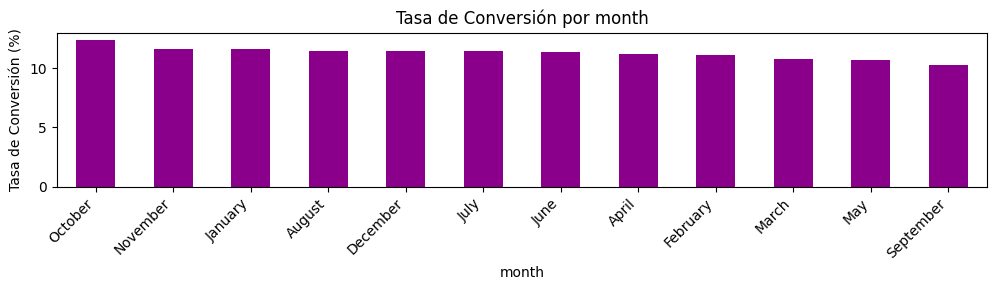

In [16]:
grafs_conversion_cat(df_final, 'subscribed', rotar_columnas=('job', 'education_level', 'month'))

***job* vs *subscribed***

- Las categorías con mayor volumen son *administrative*, *blue-collar* y *technician*, sin embargo, tienen menor tasa de conversión que otras categorías.
- Los *students* y *retired* presentan una mayor proporción de suscripción.

Conclusión: La ocupación influye en la suscripción; perfiles como estudiantes y jubilados tienden a suscribirse más.

***marital_status* vs *subscribed***

- La mayoría de los clientes están casados (*married*).
- Los *single* presentan una proporción ligeramente mayor de suscripción.

Conclusión: El estado civil influye ligeramente; los solteros tienden a suscribirse más.

***education_level* vs *subscribed***

- La mayoría de los clientes tienen *university_degree* o *high_school*.
- Los clientes con educación universitaria muestran mayor proporción de suscripción.
- Los niveles básicos presentan menor conversión.

Conclusión: A mayor nivel educativo, mayor probabilidad de suscripción.

***default* vs *subscribed***

- La gran mayoría de los clientes no tiene historial de impagos.
- Hay muy pocos casos con default, lo que dificulta el análisis.

Conclusión: Variable poco informativa debido a su desbalance.

***housing_loan* vs *subscribed***

- La distribución entre clientes con y sin préstamo hipotecario es bastante equilibrada.
- Los que no tienen préstamo muestran una ligera mayor proporción de suscripción.

Conclusión: Tener préstamo hipotecario podría reducir levemente la probabilidad de suscripción, pero el efecto es bajo.

***personal_loan* vs *subscribed***

- La mayoría de los clientes no tiene préstamo personal.
- Los clientes sin préstamo personal presentan mayor proporción de suscripción.

Conclusión: Tener préstamos personales puede estar asociado con menor probabilidad de suscripción.

***contact_method* vs *subscribed***

- El contacto por móvil muestra muchas más suscripciones que el teléfono fijo.

Conclusión: El canal de contacto es un factor importante; el móvil es más efectivo.

***previous_campaign_outcome* vs *subscribed***

- Los clientes con resultado previo positivo tienen una tasa de suscripción muy alta.
- Los casos negativos presentan baja conversión.
- En los casos en los que no hubo contacto en la campaña previa la conversión es moderada.

Conclusión: El resultado de campañas anteriores es uno de los factores más determinantes.

***contacted_before* vs *subscribed***

- Los clientes contactados previamente tienen mayor proporción de suscripción.
- Los no contactados muestran menor conversión.

Conclusión: El seguimiento previo aumenta la probabilidad de suscripción.

***month* vs *subscribed***

- La distribución de suscripciones es relativamente uniforme entre meses.
- Algunos meses muestran ligeras variaciones, pero sin diferencias fuertes.

Conclusión: El mes tiene un impacto limitado en la suscripción.

### <span style="color:darkgray">**4. Análisis multivariado**</span>  

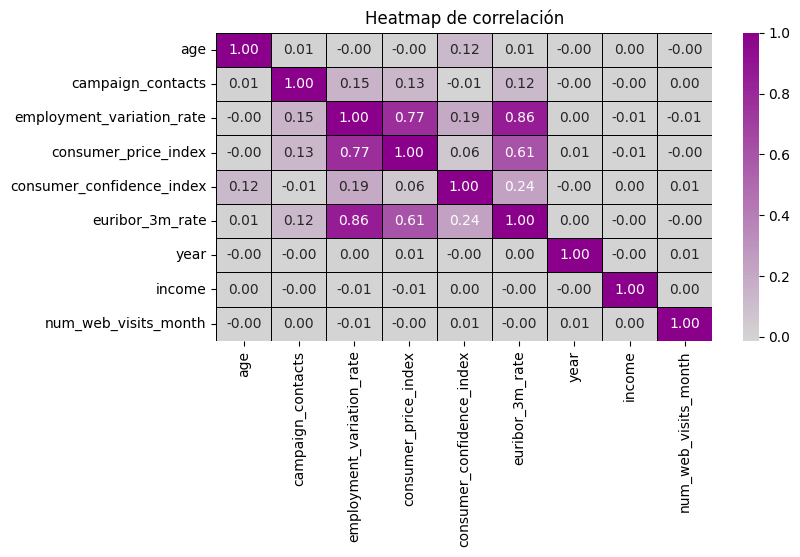

In [17]:
# Seleccionar solo columnas numéricas
col_num = df_final.select_dtypes(include='number')

# Matriz de correlación
corr = col_num.corr()

# Mapa de colores personalizado
colors = ["white", "lightgrey", "darkmagenta"]  # baja → alta correlación
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# Dibujar el heatmap
plt.figure(figsize=(8, 4)) 
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    center=0, 
    linewidths=0.5, 
    linecolor='black'
    )
plt.title("Heatmap de correlación")
plt.show()

🟣 **Correlaciones más fuertes (positivas):**

**`employment_variation_rate` ↔ `euribor_3m_rate` (0.86)**

- Relación muy fuerte: cuando uno sube, el otro también.

**`employment_variation_rate` ↔ `consumer_price_index` (0.77)**

- Cuando sube el empleo, tiende a subir el índice de precios (inflación).

**`consumer_price_index` ↔ `euribor_3m_rate` (0.61)**

- Relación moderada-alta entre precios e interés.

🟢 **Correlaciones moderadas:**

**`consumer_confidence_index` ↔ euribor_3m_rate` (0.24)**

- Cuando suben las tasas de interés, la confianza del consumidor tiende a cambiar ligeramenteç.

**`employment_variation_rate` ↔ `consumer_confidence_index` (0.19)** 

- Un aumento en el empleo se asocia con un pequeño aumento en la confianza.

**`campaign_contacts` ↔ `employment_variation_rate` (0.15)** 

- El número de contactos en campañas tiene una leve relación con el empleo, pero su influencia es muy limitada.

⚪ **Correlaciones débiles o casi nulas:**  

**`age`, `income`, `year`, `num_web_visits_month`**

- Estas variables tienen valores cercanos a 0, indicando poca o ninguna relación lineal con las demás.

🔴 **Correlaciones negativas:**

- No hay relaciones negativas relevantes (todas están cerca de 0).


---
---
## <span style="color:gray">**Insights**</span> 💡

El análisis exploratorio muestra que las variables macroeconómicas, especialmente `employment_variation_rate` y `euribor_3m_rate`, presentan la mayor relación con la suscripción. Además, estas variables están fuertemente correlacionadas entre sí, lo que indica posible multicolinealidad.

Por otro lado, variables individuales como `age`, `income` y `num_web_visits_month` presentan correlaciones débiles, sugiriendo una baja influencia directa en la decisión del cliente.

En cuanto a variables categóricas, `previous_campaign_outcome` destaca como el factor más influyente, seguido por `contact_method` y `jo`b. Variables como `education_level` y `marital_status` muestran un impacto moderado, mientras que `default`, `housing_loan` y `personal_loan` tienen poca relevancia.

Finalmente, se observa que `campaign_contacts` no presenta una relación positiva clara con la suscripción, lo que indica que un mayor número de contactos no necesariamente mejora los resultados.

---
---
## <span style="color:gray">**Conclusiones finales**</span> 📝

Los resultados sugieren que la decisión de suscripción está más influenciada por factores externos, como las condiciones macroeconómicas, que por características personales del cliente.

El historial de campañas emerge como el factor más determinante, lo que indica que la información de interacciones previas es clave para predecir el comportamiento futuro.

Asimismo, el canal de contacto y ciertas variables sociodemográficas (como la ocupación) juegan un papel relevante, mientras que variables financieras como préstamos tienen un impacto limitado.

Dado que algunas variables macroeconómicas contienen información redundante, es recomendable realizar una selección cuidadosa de variables para evitar problemas de multicolinealidad en los modelos predictivos.

Por último, incrementar la cantidad de contactos no garantiza una mayor tasa de conversión, por lo que se recomienda optimizar la estrategia de contacto en lugar de simplemente aumentarla.